# Cosine vs linear schedule

A schedule is a _budget_: T steps to spend across the range of noise levels, and
`ᾱ_t` says how much of the image survives at each one. Linear betas spend that
budget badly on 28x28 images -- the signal is half gone by t≈259 and half of all
steps sit in near-pure noise, where there is little left to learn. Cosine
(`cosine_schedule.py`, Nichol & Dhariwal) holds `ᾱ` near a straight line down to
zero instead.

Nothing here is trained. Both schedules are closed-form, so this is a property
of the arithmetic, not of a checkpoint.

**Run the setup cell once, then the graph cell.**


## Setup


In [1]:
# --- setup: both schedules, one digit to corrupt. Run this once. ---
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from forward_process import ForwardProcess
from utils import repo_root

dev = "cpu"  # 1000-element schedules; a GPU buys nothing here
T = 1000

fps = {
    "linear": ForwardProcess(T, schedule="linear"),
    "cosine": ForwardProcess(T, schedule="cosine"),
}
COLOR = {"linear": "tab:orange", "cosine": "tab:blue"}
ac = {k: v.alphas_cumprod.double() for k, v in fps.items()}
snr = {k: v / (1 - v) for k, v in ac.items()}  # the only thing t actually means

_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
ds = datasets.MNIST(root=repo_root() / "data", train=True, transform=_tf)


def crossing(curve, level):
    """First t where the curve has fallen below `level`."""
    below = (curve < level).nonzero()
    return int(below[0]) if len(below) else T


def noised_row(x0, ts, fp, eps):
    """x_t at each t in ts, all from the SAME eps so the schedules are paired."""
    return torch.stack(
        [fp.q_sample(x0[None], torch.tensor([t]), eps[None])[0] for t in ts]
    )


for k in fps:
    print(
        f"{k:>7}: ᾱ<0.5 at t={crossing(ac[k], 0.5):3d}   "
        f"SNR<1 at t={crossing(snr[k], 1.0):3d}   "
        f"steps at SNR<0.1: {(snr[k] < 0.1).double().mean():.0%}   "
        f"ᾱ_T={ac[k][-1]:.2e}"
    )

 linear: ᾱ<0.5 at t=259   SNR<1 at t=259   steps at SNR<0.1: 52%   ᾱ_T=4.04e-05
 cosine: ᾱ<0.5 at t=496   SNR<1 at t=496   steps at SNR<0.1: 20%   ᾱ_T=2.43e-09


## Where the T steps go


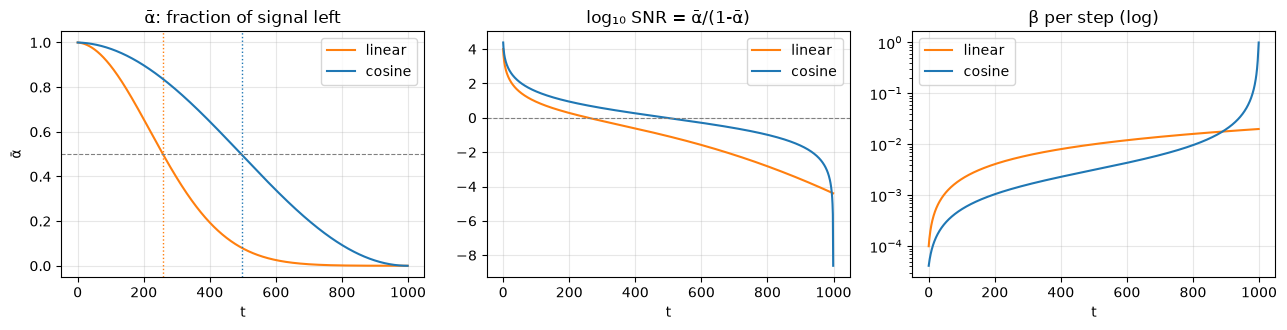

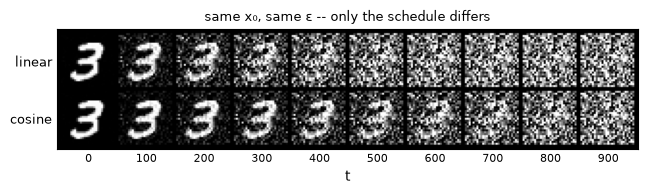

In [ ]:
# --- the comparison ---
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

for k, fp in fps.items():
    axes[0].plot(ac[k], color=COLOR[k], label=k)
    axes[1].plot(snr[k].log10(), color=COLOR[k], label=k)
    axes[2].plot(fp.betas, color=COLOR[k], label=k)
    # where half the signal is gone -- the headline number
    axes[0].axvline(crossing(ac[k], 0.5), color=COLOR[k], ls=":", lw=1)

axes[0].axhline(0.5, color="grey", ls="--", lw=0.8)
axes[0].set_title("ᾱ: fraction of signal left")
axes[0].set_ylabel("ᾱ")
axes[1].axhline(0.0, color="grey", ls="--", lw=0.8)  # log10 SNR = 0, i.e. SNR = 1
axes[1].set_title("log₁₀ SNR = ᾱ/(1-ᾱ)")
axes[2].set_yscale("log")
axes[2].set_title("β per step (log)")
for a in axes:
    a.set_xlabel("t")
    a.grid(alpha=0.3)
    a.legend()
plt.tight_layout()
plt.show()

# the same claim on an actual digit: one image, one fixed eps, both schedules
ts = list(range(0, T, 100))
x0 = ds[7][0]
torch.manual_seed(0)
eps = torch.randn_like(x0)
rows = torch.cat([noised_row(x0, ts, fps[k], eps) for k in fps])

pad, w = 2, x0.shape[-1]
grid = make_grid(rows, nrow=len(ts), normalize=True, value_range=(-1, 1), padding=pad)
plt.figure(figsize=(len(ts) * 0.75, 2.0))
plt.imshow(grid.permute(1, 2, 0))
plt.xticks([pad + j * (w + pad) + w / 2 for j in range(len(ts))], ts, fontsize=8)
plt.yticks(
    [pad + i * (w + pad) + w / 2 for i in range(len(fps))], list(fps), fontsize=9
)
plt.xlabel("t")
plt.tick_params(length=0)
plt.title("same x₀, same ε -- only the schedule differs", fontsize=9)
plt.show()